In [2]:
import yfinance as yf
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

symbol = 'AMZN'
start_date = '2021-01-01'
end_date = '2026-8-31'

stock = yf.Ticker(symbol)
historical_data = stock.history(start=start_date, end=end_date)
closing_price = historical_data["Close"]
print(closing_price)

Date
2021-01-04 00:00:00-05:00    159.331497
2021-01-05 00:00:00-05:00    160.925507
2021-01-06 00:00:00-05:00    156.919006
2021-01-07 00:00:00-05:00    158.108002
2021-01-08 00:00:00-05:00    159.134995
                                ...    
2026-08-24 00:00:00-04:00    262.070007
2026-08-25 00:00:00-04:00    261.059998
2026-08-26 00:00:00-04:00    260.279999
2026-08-27 00:00:00-04:00    256.260010
2026-08-28 00:00:00-04:00    266.429993
Name: Close, Length: 1420, dtype: float64


Date
2021-01-05 00:00:00-05:00    1.000436
2021-01-06 00:00:00-05:00   -2.489661
2021-01-07 00:00:00-05:00    0.757713
2021-01-08 00:00:00-05:00    0.649551
2021-01-11 00:00:00-05:00   -2.151946
                               ...   
2026-08-24 00:00:00-04:00    1.330086
2026-08-25 00:00:00-04:00   -0.385397
2026-08-26 00:00:00-04:00   -0.298781
2026-08-27 00:00:00-04:00   -1.544486
2026-08-28 00:00:00-04:00    3.968619
Name: Close, Length: 1419, dtype: float64


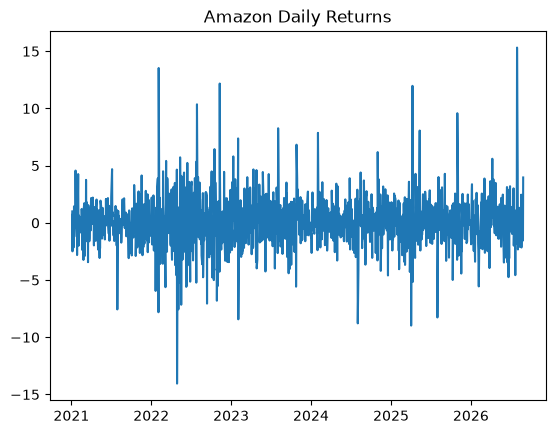

In [3]:
# daily_returns = []
# for i in range(1, len(closing_price)):
#     prev, today = closing_price.iloc[i - 1], closing_price.iloc[i]
#     daily_returns.append(float((today - prev) / prev) * 100)
# The pandas version of this:
daily_returns = closing_price.pct_change().dropna() * 100
print(daily_returns)

plt.plot(daily_returns)
plt.title("Amazon Daily Returns")
plt.show()

## Research / Understanding

Typically, we might model returns as $r_t = \mu + \epsilon_t$, where $\epsilon_t$ is like the "unpredictable shock" at time t (error term). With normal regression, we typically assume that the $\epsilon_t$ term has a normal distribution where the variance is a constant (i.e. $\epsilon_t \sim N(0, \sigma^2)$)

However, in many real life scenarios and especially in finance, this is not true - variance almost certainly varies. For example, if some world
event causes the market to crash, your returns will likely be drastically different than before this event. While the average/mean may stay
the same, the variance will likely explode!

Moreover, after these events, values tend to move _together_. That is, large errors tend to be followed by large errors; shocks can create elevated periods of uncertainty instead of only affecting ONE time instant. For example, if something happens at $t - 1$, it is very likely that time $t$ will be digesting it.

This is where ARCH (Autoregressive Conditional Heteroskedasticity) comes in. Instead of modelling variance as a constant term, it becomes a function of the past residuals:

$$
\text{ARCH}(p): \sigma_t^2 = \alpha_0 + \sum_{i=1}^{p} \alpha_i \epsilon_{t-i}^2
$$

where $p$ is the number of time periods to take into consideration (also called the _lag_ parameter). For example, if $p=1$, we would get:

$$
\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2
$$

As one may expect, ARCH typically assumes that the mean process has already been made stationary, so changes in the residuals can be interpreted as changes in volatility rather than changes in the mean. 

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) is an extension of ARCH that incorporates a moving average component. More specifically, this model includes __lag variance__ terms in addition to the lag residuals to more accurately capture __volitility persistence__. The formula for the variance calulcated this way is:

$$
\text{GARCH}(p, q): \sigma_t^2 = \omega + \sum_{i=1}^{p}\alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{q}\beta_j \sigma_{t-j}^2
$$

where $p$ is the number of lagged square residuals and $q$ is the number of lagged variances. For example, with $p=1$ and $q=1$:

$$ \sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2 $$

Just like with ARCH, GARCH assumes the mean process is stationary.

In [ ]:
# Test to see if this data has a constant mean using the ADF test.
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_returns)
print("ADF statistic:", result[0])
print(f"p-value: {result[1]:.20e}")
print("Critical values:", result[4])

ADF statistic: -37.17855887646782
p-value: 0.00000000000000000000e+00
Critical values: {'1%': np.float64(-3.4349700122033804), '5%': np.float64(-2.8635804131233096), '10%': np.float64(-2.567856305330816)}


/var/folders/lr/j24s_bfs3gq2mpzj68hxqz2m0000gn/T/ipykernel_82657/1083228451.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(daily_returns)


With a p-value that small, there is very strong evidence against the null hypothesis (that we have a non-constant mean). Thus, we will reject it and conclude that we have a unit root. GARCH applies!

The next thing we look for is autocorrelation, which simply refers to how correlated a series is with a _delayed/lagged version of itself_. An Autocorrelation Function (ACF) plot helps us visualize this information. 

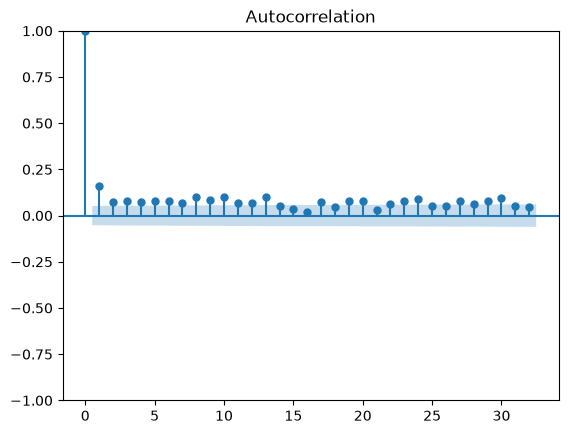

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

abs_daily_returns = abs(daily_returns)
plot_acf(abs_daily_returns)
plt.show()

Note the blue band in the graph - this is a confidence band for the autocorrelation under the null hypothesis (that the true autocorrelation is 0).

From this, we can see that many of the points are positively correlated and outside the blue confidence band ("this correlation is large enough that it would be unlikely to arise purely by chance if the true correlation at that lag were zero"). 

We can conclude that the magnitude of the residuals is positively autocorrelated over time, or that there is volatility clustering/persistence!

With this, we can pretty confidently proceed with creating an ARCH/GARCH model!

Available forecasts: 284


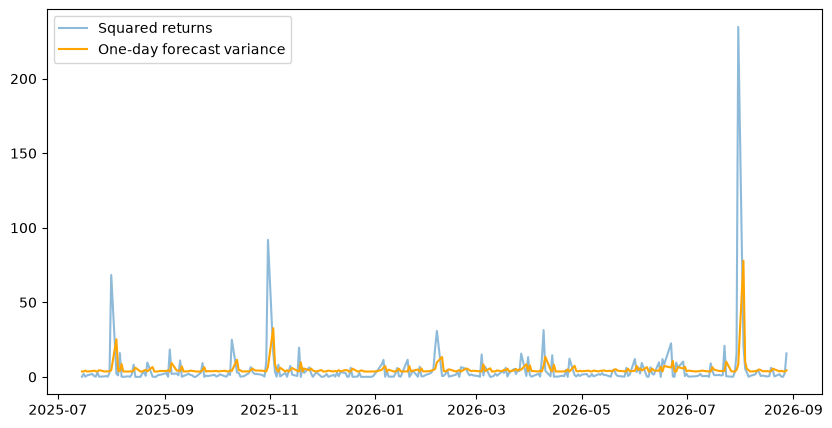

In [21]:
from arch import arch_model

# Create train and test split, 80% to 20% respectively.
index = int(len(daily_returns) * 0.8)
train, test = daily_returns.iloc[:index], daily_returns[index:]
p, q = 1, 1

# ARCH model.
arch = arch_model(
    daily_returns,
    mean="Zero",
    vol="ARCH",
    p=p
)

model = arch.fit(last_obs=index, disp="off")

forecast = model.forecast(
    start=index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

print("Available forecasts:", forecast_variance.notna().sum())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test**2, label="Squared returns", alpha=0.5)
plt.plot(
    test.index,
    forecast_variance,
    label="One-day forecast variance",
    color="orange"
)
plt.legend()
plt.show()

Available forecasts: 284


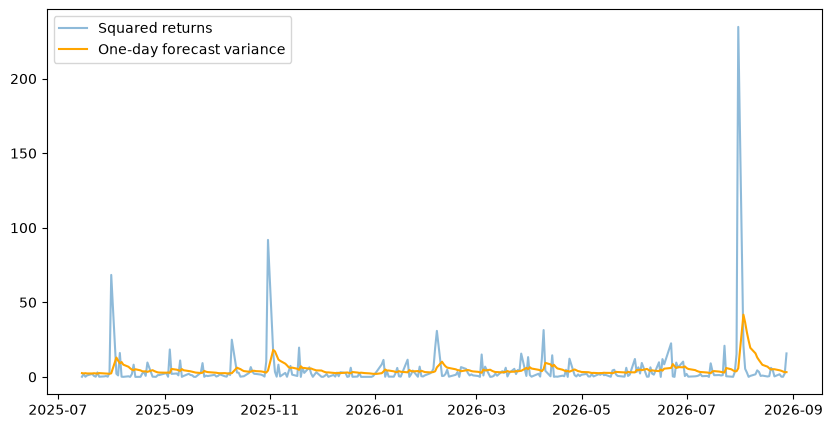

In [22]:
# GARCH.
garch = arch_model(
    daily_returns,
    mean="Zero",
    vol="GARCH",
    p=p,
    q=q
)

model = garch.fit(last_obs=index, disp="off")

forecast = model.forecast(
    start=index - 1,
    horizon=1,
    align="target",
    reindex=True
)

forecast_variance = forecast.variance["h.1"].loc[test.index]

print("Available forecasts:", forecast_variance.notna().sum())

plt.figure(figsize=(10, 5))
plt.plot(test.index, test**2, label="Squared returns", alpha=0.5)
plt.plot(
    test.index,
    forecast_variance,
    label="One-day forecast variance",
    color="orange"
)
plt.legend()
plt.show()


Okay time to improve on the $p$ and $q$ values, or possibly even prove that $p=1$ and $q=1$ are optimal.